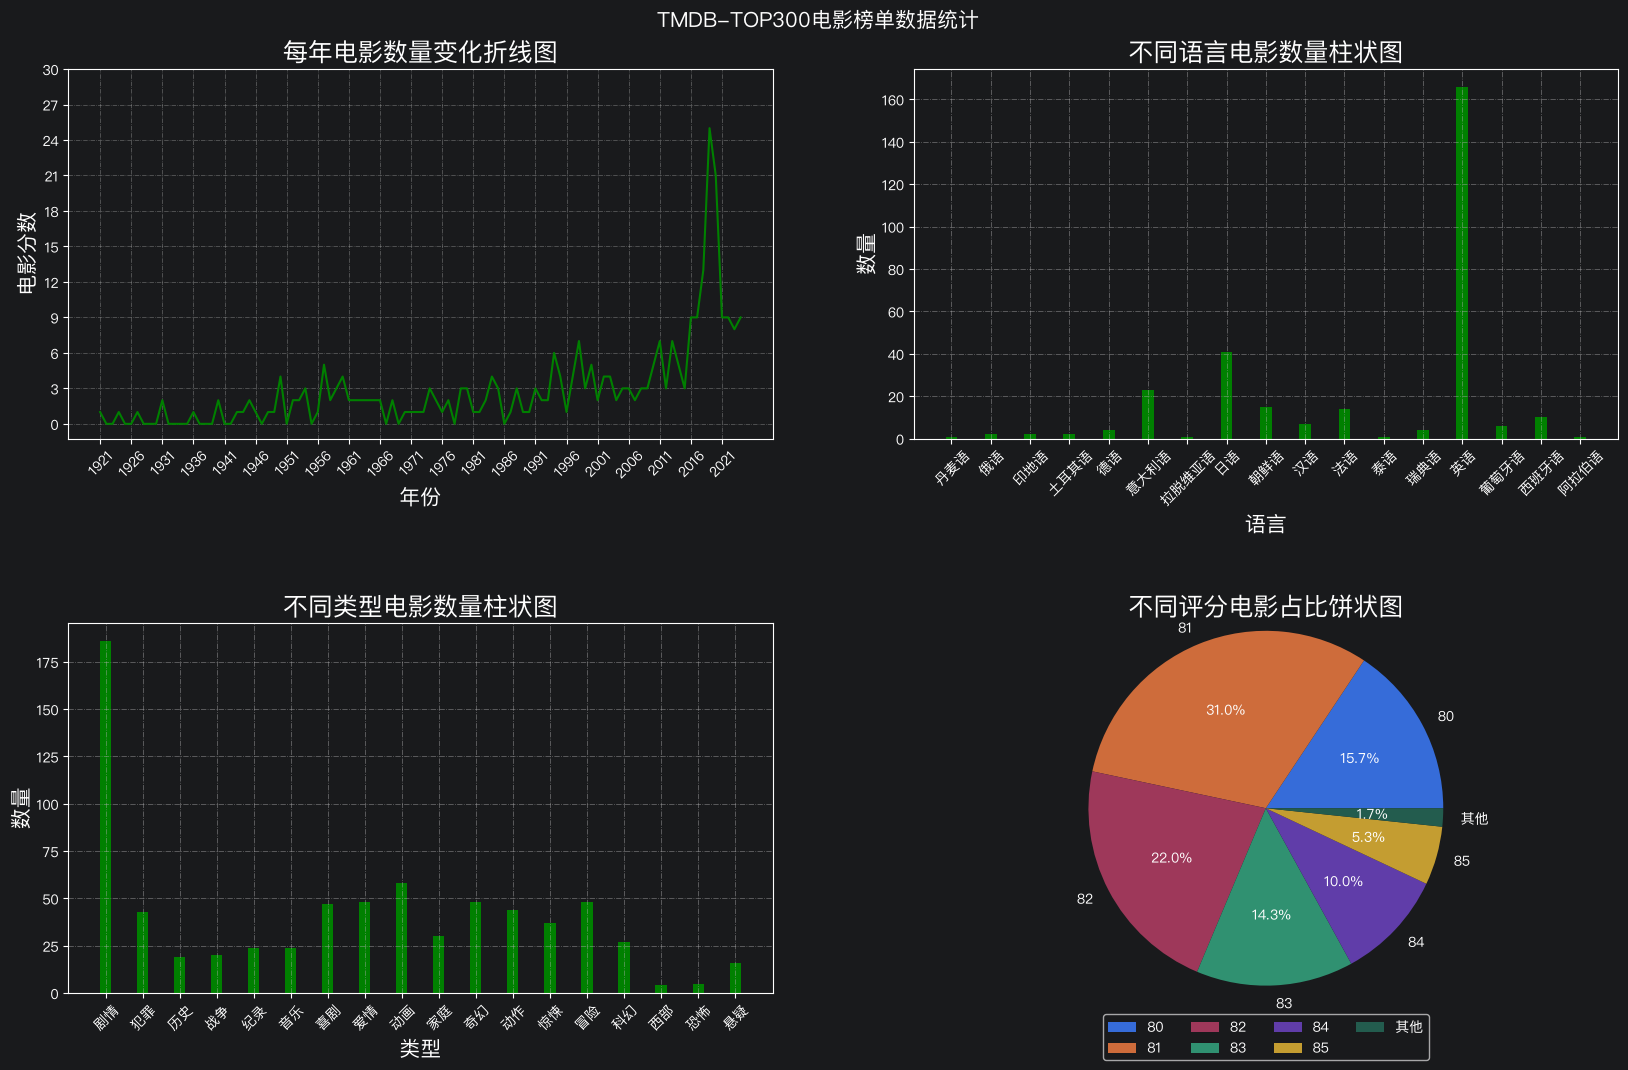

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.mpl_axes import Axes

# 设置中文
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块

# 创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), dpi=100)
fig.suptitle('TMDB-TOP300电影榜单数据统计', fontsize=15, x=0.5, y=0.93)
fig.subplots_adjust(hspace=0.5, wspace=0.2) # 调整子图的间距，hspace：控制垂直间距，wspace：控制水平间距

# 获取到4个子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
data = pd.read_csv('resources/movies.csv',  usecols=['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'], dtype={'年份': 'Int64'})

# 数据清洗
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 分组
year_count = data.groupby('年份')['年份'].count()

# 组装x轴数据
x = [i for i in range(year_count.index.min(), year_count.index.max())]
# 组装y轴数据
y = [year_count.get(i, 0) for i in x]

axes1.plot(x, y, color='green')
axes1.set_title('每年电影数量变化折线图', fontsize=18)
axes1.set_xlabel('年份', fontsize=15)
axes1.set_ylabel('电影分数', fontsize=15)
axes1.set_xticks(x[::5])
axes1.set_yticks([i for i in range(0, 31, 3)])
axes1.grid(linestyle='-.', linewidth=0.5)
axes1.tick_params(axis='x', rotation=45)

language_count = data.groupby('语言')['语言'].count()

x_language = language_count.index.tolist()
y_language = language_count.values.tolist()

axes2.bar(x_language, y_language, color='green', width=0.3, align='center')
axes2.set_title('不同语言电影数量柱状图', fontsize=18)
axes2.set_xlabel('语言', fontsize=15)
axes2.set_ylabel('数量', fontsize=15)
axes2.grid(linestyle='-.', linewidth=0.6)
axes2.tick_params(axis='x', rotation=45)

type_count = dict()
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count.keys():
            type_count[type] += 1
        else:
            type_count[type] = 1

x_types = list(type_count.keys()) # 类型列表
y_types = list(type_count.values()) # 数量列表

axes3.bar(x_types, y_types, color='green', width=0.3, align='center')
axes3.set_title('不同类型电影数量柱状图', fontsize=18)
axes3.set_xlabel('类型', fontsize=15)
axes3.set_ylabel('数量', fontsize=15)
axes3.grid(linestyle='-.', linewidth=0.6)
axes3.tick_params(axis='x', rotation=45)

score_count = data.groupby('评分')['评分'].count()

total = score_count.sum()

total = score_count.sum()
large_score = score_count.loc[score_count >= total * 0.02]
small_score = score_count.loc[score_count < total * 0.02]

if small_score.shape[0] > 0:
    large_score['其他'] = small_score.sum()

scores = large_score.index.tolist()
scores_values = large_score.values.tolist()

# 绘制饼状图
axes4.pie(scores_values, labels=scores, autopct='%1.1f%%', shadow=False, startangle=0, radius=1.2)
axes4.set_title('不同评分电影占比饼状图', fontsize=18)
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))

plt.show()